# let's histogram

Histograma das durações de cada percept com regressão gamma


In [ ]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [11]:
tsv_folder = "../data/keypress-events-tsv"

# get list of tsv files inside this folder
tsv_files = glob.glob(os.path.join(tsv_folder, "*task-UA*_events.tsv"))

print(f"Found {len(tsv_files)} tsv files in {tsv_folder}")

Found 60 tsv files in ../data/keypress-events-tsv


In [16]:
# let's iterate over all the tsv files and retrieve the durations of the 'coherent' and 'incoherent' conditions

# Initialize an empty list to hold all durations and their types
all_durations = []

for tsv_file in tsv_files:
    df = pd.read_csv(tsv_file, sep="\t")

    for trial_type in ["coherent", "incoherent"]:
        durations = df.loc[df["trial_type"] == trial_type, "duration"].values
        all_durations.extend((d, trial_type) for d in durations)

# Create the final DataFrame
df = pd.DataFrame(all_durations, columns=["duration", "trial_type"])
df

,duration,trial_type
0,2.5,coherent
1,5.0,coherent
2,2.5,coherent
3,7.5,coherent
4,2.5,coherent
...,...,...
2227,2.5,incoherent
2228,7.5,incoherent
2229,2.5,incoherent
2230,12.5,incoherent


In [21]:
# summarize df
df_summary = df.groupby("trial_type")["duration"].describe()
df_summary

,count,mean,std,min,25%,50%,75%,max
trial_type,,,,,,,,
coherent,1154.0,7.906196,10.354489,0.5,2.5,5.0,9.0,120.0
incoherent,1078.0,4.855751,4.082050,0.5,2.5,4.0,6.0,58.0


In [22]:
# remove outliers from df
def remove_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]


df_cleaned = remove_outliers(df, "duration")
df_cleaned_summary = df_cleaned.groupby("trial_type")["duration"].describe()
df_cleaned_summary

,count,mean,std,min,25%,50%,75%,max
trial_type,,,,,,,,
coherent,1020.0,5.202206,3.482746,0.5,2.5,4.5,7.0,15.0
incoherent,1061.0,4.550189,3.074394,0.5,2.5,4.0,6.0,15.0


Text(0.5, 0, 'Duration (s)')

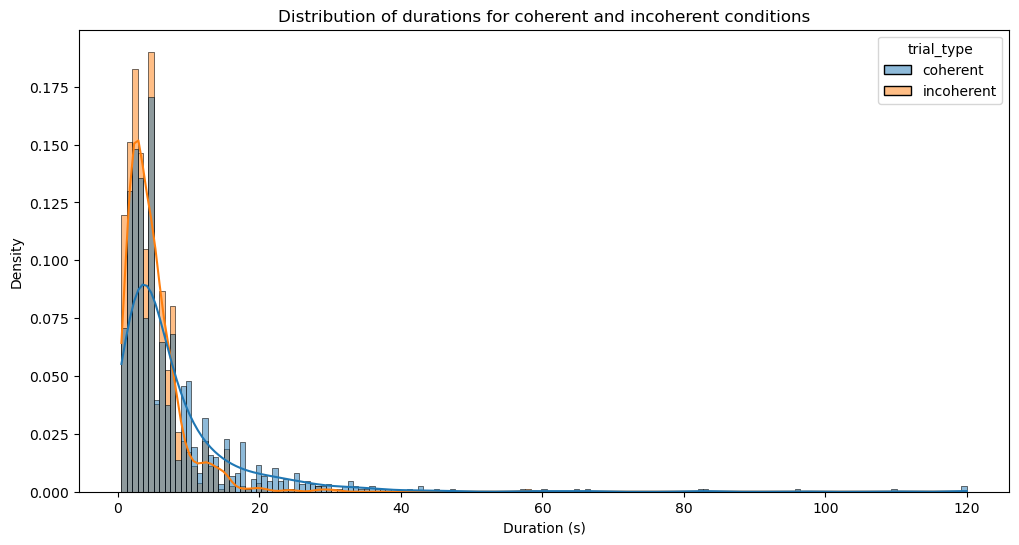

In [27]:
# create histogram of the durations for coherent and incoherent conditions
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="duration",
    hue="trial_type",
    # bins=15,
    kde=True,
    stat="density",
    common_norm=False,
    alpha=0.5,
)
plt.title("Distribution of durations for coherent and incoherent conditions")
plt.xlabel("Duration (s)")